# **CHURN PREDICTION**

We define churn (e.g., customer has no orders in last 3 months) and build classification models to predict churners. We may engineer features such as recency or purchase frequency. We evaluate Logistic Regression and Random Forest, comparing ROC curves and AUC.

In [46]:
# Import core libraries for EDA and modeling
import warnings
warnings.filterwarnings('ignore')
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, mean_squared_error

In [47]:
master_df = pd.read_pickle("Dataset/Cleaned_data/master_df.pkl")
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CustomerID             52924 non-null  str           
 1   Transaction_ID         52924 non-null  str           
 2   Transaction_Date       52924 non-null  datetime64[us]
 3   Month                  52924 non-null  str           
 4   Date                   52924 non-null  object        
 5   Week                   52924 non-null  str           
 6   Product_SKU            52924 non-null  str           
 7   Product_Description    52924 non-null  str           
 8   Product_Category       52924 non-null  str           
 9   ABC                    52924 non-null  str           
 10  Quantity               52924 non-null  int64         
 11  Avg_Price              52924 non-null  float64       
 12  Delivery_Charges       52924 non-null  float64       
 13  Revenue     

Logistic Regression AUC: 1.00, Random Forest AUC: 1.00


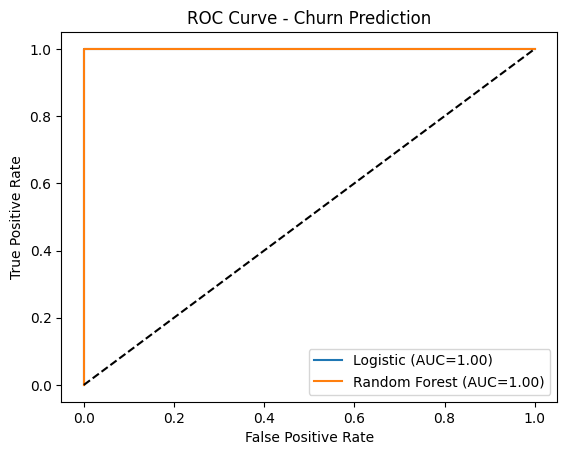

In [48]:
# Prepare data for churn prediction
if 'Recency' in master_df.columns:
    # Example: label churn = 1 if Recency > threshold
    churn_threshold = 90
    master_df['Churn'] = (master_df['Recency'] > churn_threshold).astype(int)
    X = master_df[['Recency', 'Frequency', 'Monetary']]
    y = master_df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    # Logistic Regression
    logreg = LogisticRegression()
    logreg.fit(X_train, y_train)
    y_pred_proba = logreg.predict_proba(X_test)[:,1]
    auc_log = roc_auc_score(y_test, y_pred_proba)
    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_proba_rf = rf.predict_proba(X_test)[:,1]
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
    print(f"Logistic Regression AUC: {auc_log:.2f}, Random Forest AUC: {auc_rf:.2f}")
    # Plot ROC curves
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
    plt.figure()
    plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC={auc_log:.2f})')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.legend()
    plt.title('ROC Curve - Churn Prediction')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

**Cohort Analysis**

We construct cohorts based on the month of first purchase to study retention. By pivoting a cohort table (cohort index vs month offset), we measure retention rates over time.

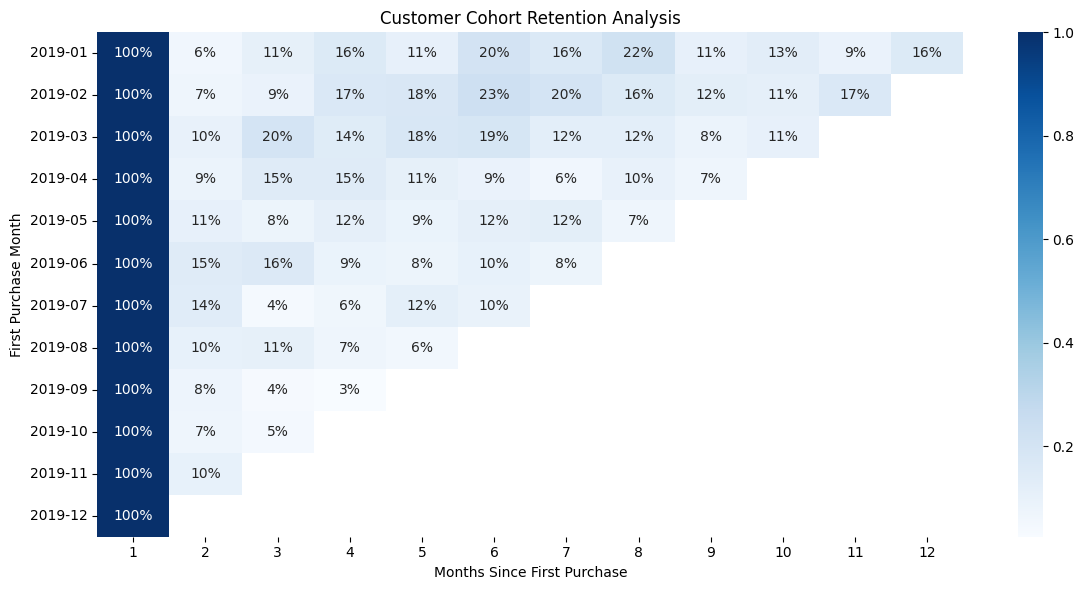

In [49]:
# Cohort analysis: assign each customer to cohort (first purchase month)
# =========================

# 1. Create Purchase Month from Transaction_Date
master_df["PurchaseMonth"] = master_df["Transaction_Date"].dt.to_period("M")

# 2. Identify the first purchase month for each customer
master_df["CohortMonth"] = (
    master_df.groupby("CustomerID")["PurchaseMonth"]
      .transform("min")
)

# 3. Count active customers by cohort and purchase month
cohort_data = (
    master_df.groupby(["CohortMonth", "PurchaseMonth"])["CustomerID"]
      .nunique()
      .reset_index()
)

# 4. Calculate the number of months since the first purchase
cohort_data["CohortPeriod"] = (
    (cohort_data["PurchaseMonth"].dt.year - cohort_data["CohortMonth"].dt.year) * 12
    + (cohort_data["PurchaseMonth"].dt.month - cohort_data["CohortMonth"].dt.month)
    + 1
)

# 5. Pivot to retention matrix
cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortPeriod",
    values="CustomerID"
)

# 6. Normalize retention %
cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
)

# 7. Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Cohort Retention Analysis")
plt.ylabel("First Purchase Month")
plt.xlabel("Months Since First Purchase")

plt.tight_layout()
plt.show()